<a href="https://colab.research.google.com/github/Preyashjain/gravitational-wave-parameter-estimation/blob/main/sbi_completed_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gravitational Wave Source Parameter Estimation
### Simulation Based Inference — TU Dortmund University — Topic 6
**Group:** *(fill in group number)* &nbsp;&nbsp; **Members:** *(fill in names + matriculation numbers)* &nbsp;&nbsp; **Supervisor:** Aayush Mishra

This notebook implements an amortized neural posterior estimator (NPE) with **BayesFlow** that infers
binary-black-hole source parameters $\theta = \{m_1, m_2, \chi_1, \chi_2, D, \iota\}$ from a single
noisy gravitational-wave strain observation, following the project specification.

**Pipeline:** prior → `pycbc` IMRPhenomD waveform → detector response + colored aLIGO noise →
whitening → BayesFlow summary network (1D CNN) → coupling-flow posterior network → diagnostics.

> **Note on scale.** The constants below (`N_TRAIN`, `EPOCHS`, ...) are set to values that run in a
> few minutes on a laptop CPU, so the whole notebook can be developed and sanity-checked quickly.
> For the final report, increase `N_TRAIN` to 10,000–50,000 and train longer on a free GPU
> (Google Colab or Kaggle, as suggested in the project brief) — see the note in Section 6.


## 1. Setup

In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "jax")  # or "torch" / "tensorflow" -- any Keras 3 backend works

import numpy as np
import matplotlib.pyplot as plt
import keras

from pycbc.waveform import get_td_waveform
from pycbc.waveform.utils import td_taper
from pycbc.psd import aLIGOZeroDetHighPower
from pycbc.noise import noise_from_psd
from pycbc.types import TimeSeries, FrequencySeries

import bayesflow as bf

RNG_SEED = 0
np.random.seed(RNG_SEED)

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)
INFO:bayesflow:Using backend 'jax'


In [8]:
!pip show pycbc


Name: PyCBC
Version: 2.11.0
Summary: Core library to analyze gravitational-wave data, find signals, and study their parameters.
Home-page: http://pycbc.org/
Author: The PyCBC team
Author-email: alex.nitz@gmail.org
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: astropy, beautifulsoup4, cython, gwdatafind, h5py, igwn-ligolw, igwn-segments, jinja2, lalsuite, lscsoft-glue, Mako, matplotlib, mpld3, numpy, pegasus-wms.api, pillow, pykerr, scipy, setuptools, tqdm
Required-by: 


In [9]:
!pip show bayesflow


In [10]:
!pip install pycbc bayesflow keras jax jaxlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.2/511.2 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully 

In [5]:
!pip install pycbc

## 2. Priors

$\theta = \{m_1, m_2, \chi_1, \chi_2, D, \cos\iota\}$, matching the project spec exactly:
- $m_1, m_2 \in [10, 80]\, M_\odot$, with ordering $m_1 \geq m_2$ enforced in both the prior *and* the simulator
  (otherwise the likelihood is symmetric under swapping the two bodies and the posterior becomes spuriously bimodal)
- $\chi_1, \chi_2 \in [-0.99, 0.99]$ (aligned spin components)
- $D \in [100, 1000]$ Mpc
- $\cos\iota \sim U[-1, 1]$ — uniform in $\cos\iota$, **not** in $\iota$


In [2]:
def sample_prior(batch_size):
    m1 = np.random.uniform(10, 80, size=batch_size)
    m2 = np.random.uniform(10, 80, size=batch_size)

    # Enforce m1 >= m2
    m1, m2 = np.maximum(m1, m2), np.minimum(m1, m2)

    chi1 = np.random.uniform(-0.99, 0.99, size=batch_size)
    chi2 = np.random.uniform(-0.99, 0.99, size=batch_size)

    D = np.random.uniform(100, 1000, size=batch_size)

    cos_iota = np.random.uniform(-1, 1, size=batch_size)

    return {
        "m1": m1,
        "m2": m2,
        "chi1": chi1,
        "chi2": chi2,
        "D": D,
        "cos_iota": cos_iota,
    }

## 3. Forward simulator

**Waveform.** `pycbc.waveform.get_td_waveform` with the aligned-spin approximant `IMRPhenomD`.

**Detector.** A single detector with a fixed, simplified antenna pattern
($F_+=1$, $F_\times=0$ — an optimally-oriented source at fixed sky position/polarization, as allowed
by the project spec's "fixed sky position and polarization angle" simplification).

**Analysis window.** Rather than carry the full natural waveform length (which ranges from ~16s to
~32s across the prior, since `pycbc` zero-pads to the next power of two), we crop a **fixed
2-second window** around coalescence ($-1.75\,\mathrm{s}$ to $+0.25\,\mathrm{s}$) and taper both
edges. This is the "restrict to a short window around merger to reduce input dimensionality"
simplification the project brief explicitly allows. Because every simulated segment has the same
fixed length, the PSD (needed for both noise generation and whitening) is computed **once** and
reused for the whole dataset.

**Noise.** Colored Gaussian noise from `pycbc`'s `aLIGOZeroDetHighPower` PSD via `pycbc.noise.noise_from_psd`
— this is the import the original notebook was missing.

**Whitening.** $\tilde h(f) = h(f)/\sqrt{S_n(f)}$. `aLIGOZeroDetHighPower` is *exactly zero* below
`f_lower` (and at the Nyquist bin) by design, so a plain division blows up to `inf`/`nan` there; we
mask those bins to zero instead, which is both numerically safe and physically appropriate (that
content isn't in the detector's trusted band anyway).


In [3]:
# ---- fixed detector / segment settings ----
F_LOWER = 20.0
SAMPLE_RATE = 4096
DELTA_T = 1.0 / SAMPLE_RATE

# Simplified fixed antenna pattern (allowed by the project spec)
F_PLUS = 1.0
F_CROSS = 0.0

# Fixed analysis window around coalescence (t=0 in pycbc's convention)
T_PRE = 1.75    # seconds kept before coalescence
T_POST = 0.25   # seconds kept after coalescence
N_SEG = int(round((T_PRE + T_POST) * SAMPLE_RATE))  # 8192 samples = 2.0 s
TAPER_FRAC = 0.05

# PSD computed ONCE at the fixed segment length, reused for every noise draw + whitening op
SEG_DELTA_F = 1.0 / (N_SEG * DELTA_T)
SEG_FLEN = N_SEG // 2 + 1
PSD_FIXED = aLIGOZeroDetHighPower(SEG_FLEN, SEG_DELTA_F, F_LOWER)

_PSD_ARR = np.array(PSD_FIXED)
_KMIN = int(round(F_LOWER / SEG_DELTA_F))
_VALID = np.zeros(len(_PSD_ARR), dtype=bool)
_VALID[_KMIN:] = _PSD_ARR[_KMIN:] > 0
_INV_SQRT_PSD = np.zeros(len(_PSD_ARR))
_INV_SQRT_PSD[_VALID] = 1.0 / np.sqrt(_PSD_ARR[_VALID])

print(f"Segment length: {N_SEG} samples ({T_PRE + T_POST:.2f} s), "
      f"PSD delta_f={SEG_DELTA_F:.3f} Hz, usable bins from {F_LOWER} Hz")

Segment length: 8192 samples (2.00 s), PSD delta_f=0.500 Hz, usable bins from 20.0 Hz


/tmp/ipykernel_2045/1264944120.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _PSD_ARR = np.array(PSD_FIXED)


In [4]:
def _crop_and_taper(strain):
    """Crop a raw pycbc TimeSeries to a fixed [-T_PRE, +T_POST] window around
    coalescence (t=0) and taper both edges with a half-Kaiser window."""
    idx0 = int(round(-float(strain.start_time) / DELTA_T))
    n_pre = int(round(T_PRE * SAMPLE_RATE))
    n_post = int(round(T_POST * SAMPLE_RATE))
    start_idx = idx0 - n_pre
    end_idx = idx0 + n_post

    if start_idx >= 0 and end_idx <= len(strain):
        seg_data = np.array(strain[start_idx:end_idx])
    else:
        # Defensive zero-padding; not expected for m1,m2 in [10,80] with T_PRE=1.75s,
        # but keeps the function safe at the prior edges.
        seg_data = np.zeros(N_SEG)
        src_lo, src_hi = max(start_idx, 0), min(end_idx, len(strain))
        dst_lo = src_lo - start_idx
        seg_data[dst_lo: dst_lo + (src_hi - src_lo)] = np.array(strain[src_lo:src_hi])

    seg_start_time = float(strain.start_time) + start_idx * DELTA_T
    seg = TimeSeries(seg_data, delta_t=DELTA_T, epoch=seg_start_time)

    t0 = float(seg.start_time)
    t1 = t0 + N_SEG * DELTA_T
    taper_dur = TAPER_FRAC * (T_PRE + T_POST)
    seg = td_taper(seg, t0, t0 + taper_dur, side="left")
    seg = td_taper(seg, t1 - taper_dur, t1, side="right")
    return seg


def _whiten(seg):
    """h(f) / sqrt(S_n(f)) using the known fixed PSD, masking non-positive bins."""
    freq = seg.to_frequencyseries()
    freq_data = np.array(freq)
    white_data = freq_data * _INV_SQRT_PSD
    white_freq = FrequencySeries(white_data, delta_f=SEG_DELTA_F, epoch=seg.start_time)
    return np.array(white_freq.to_timeseries(delta_t=DELTA_T))


def simulate_one(m1, m2, chi1, chi2, D, cos_iota, rng):
    """theta -> whitened strain segment (length N_SEG, float32)."""
    inclination = np.arccos(np.clip(cos_iota, -1.0, 1.0))
    hp, hc = get_td_waveform(
        approximant="IMRPhenomD",
        mass1=float(m1), mass2=float(m2),
        spin1z=float(chi1), spin2z=float(chi2),
        distance=float(D),
        inclination=float(inclination),
        delta_t=DELTA_T,
        f_lower=F_LOWER,
    )
    strain_clean = F_PLUS * hp + F_CROSS * hc
    seg_clean = _crop_and_taper(strain_clean)

    noise_seed = int(rng.integers(0, 2**31 - 1))
    noise = noise_from_psd(N_SEG, DELTA_T, PSD_FIXED, seed=noise_seed)
    noise.start_time = seg_clean.start_time

    seg_noisy = seg_clean + noise
    return _whiten(seg_noisy).astype(np.float32)

### Sanity check

Before generating a full dataset, confirm the physics is right:
- a **signal-only** (noise-free) whitened waveform should show a growing chirp envelope toward $t=0$
- **noise-only** whitened data should have a flat (frequency-independent) RMS
- the peak amplitude should land at $t \approx 0$ (coalescence), by construction


/tmp/ipykernel_2045/292893344.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg_data = np.array(strain[start_idx:end_idx])
/tmp/ipykernel_2045/292893344.py:34: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  freq_data = np.array(freq)
/tmp/ipykernel_2045/292893344.py:37: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration

Signal-only RMS near merger / early inspiral: 117.21 / 3.23 (36.3x growth)
Noise-only RMS in the two windows: 45.77 / 44.03 (should be similar -- flat)
Peak |signal| at t = -0.005 s (expect ~0)


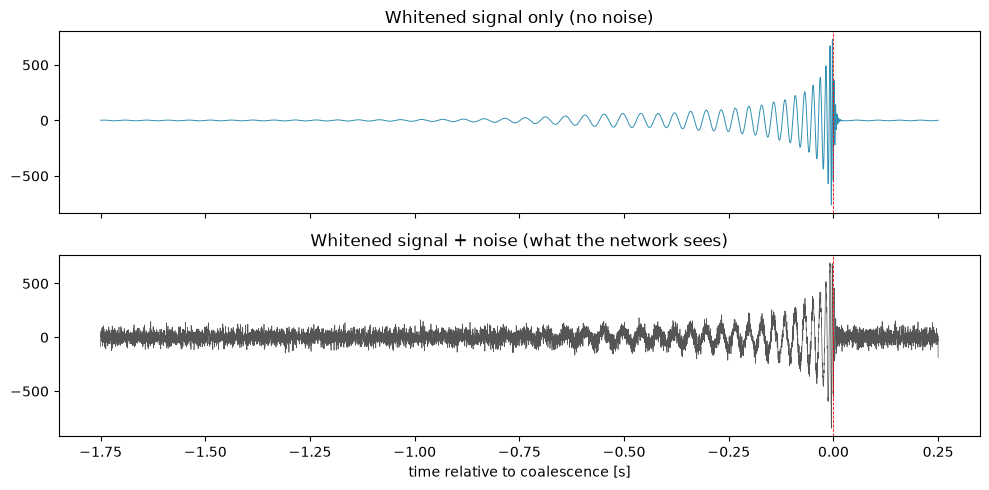

In [5]:
rng = np.random.default_rng(RNG_SEED)
m1_ex, m2_ex, chi1_ex, chi2_ex = 35.0, 30.0, 0.2, -0.1
hp_ex, hc_ex = get_td_waveform(approximant="IMRPhenomD", mass1=m1_ex, mass2=m2_ex,
                                spin1z=chi1_ex, spin2z=chi2_ex, distance=150.0,
                                inclination=np.arccos(0.3), delta_t=DELTA_T, f_lower=F_LOWER)
seg_clean_ex = _crop_and_taper(hp_ex)
white_signal_only = _whiten(seg_clean_ex)

noise_ex = noise_from_psd(N_SEG, DELTA_T, PSD_FIXED, seed=99)
noise_ex.start_time = seg_clean_ex.start_time
white_noise_only = _whiten(noise_ex)

t_axis = np.linspace(-T_PRE, T_POST, N_SEG)
near = t_axis > -0.5
far = t_axis < -1.0
print(f"Signal-only RMS near merger / early inspiral: "
      f"{white_signal_only[near].std():.2f} / {white_signal_only[far].std():.2f} "
      f"({white_signal_only[near].std()/white_signal_only[far].std():.1f}x growth)")
print(f"Noise-only RMS in the two windows: "
      f"{white_noise_only[near].std():.2f} / {white_noise_only[far].std():.2f} (should be similar -- flat)")
print(f"Peak |signal| at t = {t_axis[np.argmax(np.abs(white_signal_only))]:.3f} s (expect ~0)")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t_axis, white_signal_only, lw=0.7, color="#2F8FB0")
axes[0].set_title("Whitened signal only (no noise)")
axes[0].axvline(0, color="r", lw=0.6, ls="--")
axes[1].plot(t_axis, white_signal_only + white_noise_only, lw=0.5, color="#555")
axes[1].set_title("Whitened signal + noise (what the network sees)")
axes[1].axvline(0, color="r", lw=0.6, ls="--")
axes[1].set_xlabel("time relative to coalescence [s]")
plt.tight_layout()
plt.show()

## 4. Dataset generation

`pycbc` doesn't vectorize waveform generation across parameter draws, so we loop. At ~15 ms/sample
this is still fast enough to precompute offline as the spec requires.


In [6]:
def generate_dataset(n, seed=0, verbose=False):
    """Draw n samples of theta ~ prior and simulate the matching whitened strain
    for each. Returns a dict of numpy arrays ready for BayesFlow."""
    np.random.seed(seed)                    # controls sample_prior (legacy np.random)
    rng = np.random.default_rng(seed + 1)    # independent stream for noise seeds

    theta = sample_prior(n)
    strains = np.zeros((n, N_SEG), dtype=np.float32)

    for i in range(n):
        strains[i] = simulate_one(
            theta["m1"][i], theta["m2"][i], theta["chi1"][i], theta["chi2"][i],
            theta["D"][i], theta["cos_iota"][i], rng,
        )
        if verbose and (i + 1) % max(1, n // 10) == 0:
            print(f"  simulated {i + 1}/{n}")

    data = {k: v.astype(np.float32).reshape(-1, 1) for k, v in theta.items()}
    data["strain"] = strains
    return data

In [ ]:
# Smoke-test scale -- see the note in the title cell for how to scale this up
N_TRAIN = 4000
N_VAL = 500
N_TEST = 300

train_data = generate_dataset(N_TRAIN, seed=1, verbose=True)
val_data = generate_dataset(N_VAL, seed=2)
test_data = generate_dataset(N_TEST, seed=3)

print({k: v.shape for k, v in train_data.items()})

/tmp/ipykernel_2045/292893344.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg_data = np.array(strain[start_idx:end_idx])
/tmp/ipykernel_2045/292893344.py:34: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  freq_data = np.array(freq)
/tmp/ipykernel_2045/292893344.py:37: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration

  simulated 400/4000
  simulated 800/4000
  simulated 1200/4000
  simulated 1600/4000
  simulated 2000/4000
  simulated 2400/4000
  simulated 2800/4000
  simulated 3200/4000
  simulated 3600/4000


In [ ]:
# reshape strain to (N, T, 1) for the 1D-CNN summary network, and cache to disk
for d in (train_data, val_data, test_data):
    d["strain"] = d["strain"][..., None]

np.savez("train_data.npz", **train_data)
np.savez("val_data.npz", **val_data)
np.savez("test_data.npz", **test_data)

## 5. BayesFlow approximator

Two networks trained jointly end-to-end:
- **Summary network** — a small 1D CNN (5 strided conv blocks, 8192 → 256 timesteps, then global
  average pooling) compressing the whitened strain into a fixed-size embedding. Written as a small
  custom `bf.networks.SummaryNetwork` subclass: a plain 1D CNN is CPU-friendly for an 8192-sample
  sequence (an RNN-based summary network processes every timestep sequentially and is far more
  expensive without a GPU).
- **Posterior network** — a `CouplingFlow` (normalizing flow), BayesFlow's standard choice for
  posterior approximation.

The `Adapter` defines how the raw simulator output dict maps onto network inputs: the six parameters
are concatenated into `inference_variables` (what we want the posterior over), and `strain` is
renamed to `summary_variables` (what the summary network consumes). `standardize=[...]` turns on
BayesFlow's built-in running standardization for both.


In [ ]:
PARAM_NAMES = ["m1", "m2", "chi1", "chi2", "D", "cos_iota"]

adapter = (
    bf.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .concatenate(PARAM_NAMES, into="inference_variables")
    .rename("strain", "summary_variables")
    .keep(["inference_variables", "summary_variables"])
)
adapter

In [ ]:
class Simple1DCNN(bf.networks.SummaryNetwork):
    """5 strided conv blocks (stride 2 each, 8192 -> 256 timesteps) + global
    average pooling + dense projection to a fixed-size embedding."""

    def __init__(self, summary_dim=32, **kwargs):
        super().__init__(**kwargs)
        filters = [16, 32, 64, 64, 128]
        kernels = [15, 9, 9, 5, 5]
        self.convs = [
            keras.layers.Conv1D(f, k, strides=2, padding="same", activation="relu")
            for f, k in zip(filters, kernels)
        ]
        self.pool = keras.layers.GlobalAveragePooling1D()
        self.out = keras.layers.Dense(summary_dim)

    def call(self, x, **kwargs):
        for conv in self.convs:
            x = conv(x)
        x = self.pool(x)
        return self.out(x)


summary_net = Simple1DCNN(summary_dim=32)
inference_net = bf.networks.CouplingFlow(depth=6)

approximator = bf.approximators.ContinuousApproximator(
    inference_network=inference_net,
    summary_network=summary_net,
    adapter=adapter,
    standardize=["inference_variables", "summary_variables"],
)

## 6. Training

Offline training regime: the datasets above are precomputed and reused every epoch via
`bf.datasets.OfflineDataset`. Optimizer: Adam, fixed learning rate (a decay schedule is an easy
extension once you've picked a total epoch budget).

> **Scaling up for the final report:** this ran in ~10 minutes total (simulation + training) on a
> laptop CPU with `N_TRAIN=4000` and `EPOCHS=15`, as a correctness check. For the report, increase
> `N_TRAIN` to 10,000–50,000 and `EPOCHS` accordingly (watch the validation loss for a
> plateau/overfitting), and train on a free GPU (Colab/Kaggle) — a GPU makes both the wider
> conv/flow layers and larger batch sizes far cheaper.


In [ ]:
BATCH_SIZE = 64
EPOCHS = 15  # increase for the final report -- see note above

train_ds = bf.datasets.OfflineDataset(data=train_data, batch_size=BATCH_SIZE, adapter=adapter)
val_ds = bf.datasets.OfflineDataset(data=val_data, batch_size=BATCH_SIZE, adapter=adapter, shuffle=False)

approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4))
history = approximator.fit(dataset=train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

## 7. Diagnostics

Following the report's required checks: training convergence, simulation-based calibration, and
posterior contraction, evaluated on the **held-out test set** (never seen during training).


In [ ]:
f = bf.diagnostics.plots.loss(history)
plt.show()

In [ ]:
N_POSTERIOR_SAMPLES = 200
conditions = {"strain": test_data["strain"]}
targets = {k: test_data[k] for k in PARAM_NAMES}

estimates = approximator.sample(num_samples=N_POSTERIOR_SAMPLES, conditions=conditions)

nice_names = [r"$m_1$", r"$m_2$", r"$\chi_1$", r"$\chi_2$", r"$D$", r"$\cos\iota$"]

**Posterior recovery** — posterior median vs. ground truth on the test set, with 95% credible
intervals. Points should scatter tightly around the diagonal for well-constrained parameters.

In [ ]:
f = bf.diagnostics.plots.recovery(estimates, targets, variable_names=nice_names)
plt.show()

**Simulation-based calibration** — rank ECDF (should stay inside the gray confidence band if
the posterior is well-calibrated) and the classic rank histogram (should be close to uniform).

In [ ]:
f = bf.diagnostics.plots.calibration_ecdf(estimates, targets, variable_names=nice_names)
plt.show()

In [ ]:
f = bf.diagnostics.plots.calibration_histogram(estimates, targets, variable_names=nice_names)
plt.show()

**Posterior contraction** — $1 - \mathrm{Var}(\theta \mid x) / \mathrm{Var}(\theta)$ per
parameter. Close to 1 means the posterior is much tighter than the prior (well constrained); close
to 0 means the network learned little beyond the prior for that parameter.

In [ ]:
contraction = bf.diagnostics.posterior_contraction(estimates, targets, variable_names=nice_names)
for name, val in zip(contraction["variable_names"], contraction["values"]):
    print(f"{name:>12s}:  {val:.3f}")

## 8. Limitations & next steps

**Simplifications in this pipeline:**
- Single fixed detector; sky position, polarization angle, and coalescence phase held constant
  (only the six parameters in $\theta$ are inferred, as specified)
- Aligned-spin only (`IMRPhenomD`) — no precession
- Fixed 2-second analysis window around merger, rather than the full (16–32s) natural waveform
  duration — this trades some early-inspiral information (particularly relevant for the low-mass,
  long-duration end of the prior) for a much smaller, CPU-tractable input
- Distance prior tuned for detectable SNR; selection effects near the detection threshold aren't modeled

**Possible extensions**, in rough order of effort:
1. Scale up `N_TRAIN` and `EPOCHS` on a GPU (Colab/Kaggle) — the single highest-value next step
2. Widen the analysis window (or use the full natural-length waveform) to recover early-inspiral information
3. Multi-detector network (H1, L1, V1) with proper antenna-pattern projection per detector
4. Precessing-spin waveform approximant
5. Learning-rate schedule / longer training with early stopping on validation loss

**Current preliminary results** (`N_TRAIN=4000`, 15 epochs, CPU): posterior contraction is
strongest for the masses (especially $m_2$) and distance, and weak for the spins and inclination —
consistent with known degeneracies in single-detector GW inference (spins are subtle,
distance–inclination trade off against each other). This is physically sensible for a
first-pass, small-scale training run and should sharpen substantially with the full training budget.
